# Machine Learning Analysis

This notebook applies machine learning methods to the Syria host-country panel dataset for the May 5 milestone.

The goal is to explore whether refugee exposure, conflict intensity, host-country group, and macroeconomic indicators can help predict host-country economic outcomes.

The current version focuses on the Syrian Civil War as a case study. The expanded dataset includes neighboring and major Syrian refugee host countries, including both neighboring and non-neighbor host groups. The dataset covers the years 2010–2024.

The models in this notebook are used for exploratory prediction, not for strong causal claims.


In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Define project paths

DATA_PATH = Path("../data/processed/syria_panel_2010_2024.csv")
FIGURE_DIR = Path("../outputs/figures")
TABLE_DIR = Path("../outputs/tables")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# Load the processed Syria panel dataset

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (135, 17)


,origin_name,origin_iso,host_name,host_iso,host_group,year,conflict_bd_best_syria,refugee_stock,asylum_seekers,host_population,refugees_per_1000,log_refugee_stock,gdp_growth,inflation,unemployment,trade_pct_gdp,current_account_pct_gdp
0,Syria,SYR,Austria,AUT,non_neighbor_european_host,2010,0.0,505,471,8363404.0,0.060382,6.226537,1.808982,1.813534,4.883,99.644883,2.942949
1,Syria,SYR,Austria,AUT,non_neighbor_european_host,2011,1203.0,903,456,8391643.0,0.107607,6.806829,2.927468,3.286579,4.637,105.775098,1.585010
2,Syria,SYR,Austria,AUT,non_neighbor_european_host,2012,50490.0,1675,694,8429991.0,0.198695,7.424165,0.628246,2.485676,4.909,105.840791,1.510000
3,Syria,SYR,Austria,AUT,non_neighbor_european_host,2013,72016.0,2748,1561,8479823.0,0.324063,7.918992,-0.250726,2.000156,5.367,104.985374,1.752992
4,Syria,SYR,Austria,AUT,non_neighbor_european_host,2014,65345.0,6653,0,8546356.0,0.778460,8.802973,0.755799,1.605812,5.674,104.496740,2.313939


In [4]:
# Check columns and missing values

print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

Columns:
['origin_name', 'origin_iso', 'host_name', 'host_iso', 'host_group', 'year', 'conflict_bd_best_syria', 'refugee_stock', 'asylum_seekers', 'host_population', 'refugees_per_1000', 'log_refugee_stock', 'gdp_growth', 'inflation', 'unemployment', 'trade_pct_gdp', 'current_account_pct_gdp']

Missing values:
origin_name                0
origin_iso                 0
host_name                  0
host_iso                   0
host_group                 0
year                       0
conflict_bd_best_syria     0
refugee_stock              0
asylum_seekers             0
host_population            0
refugees_per_1000          0
log_refugee_stock          0
gdp_growth                 1
inflation                  0
unemployment               1
trade_pct_gdp              1
current_account_pct_gdp    1
dtype: int64


In [5]:
# Quick overview of countries, groups, and years

print("Host countries:", df["host_name"].unique())
print("Year range:", df["year"].min(), "-", df["year"].max())

if "host_group" in df.columns:
    print("\nHost groups:")
    print(df[["host_name", "host_group"]].drop_duplicates().sort_values(["host_group", "host_name"]))

df.groupby("host_name")["year"].agg(["min", "max", "count"])


Host countries: <StringArray>
[    'Austria',     'Germany',       'Egypt',        'Iraq',      'Jordan',
     'Lebanon', 'Netherlands',      'Sweden',      'Turkey']
Length: 9, dtype: str
Year range: 2010 - 2024

Host groups:
       host_name                  host_group
45          Iraq            neighboring_host
60        Jordan            neighboring_host
75       Lebanon            neighboring_host
120       Turkey            neighboring_host
0        Austria  non_neighbor_european_host
15       Germany  non_neighbor_european_host
90   Netherlands  non_neighbor_european_host
105       Sweden  non_neighbor_european_host
30         Egypt  regional_non_neighbor_host


,min,max,count
host_name,,,
Austria,2010,2024,15
Egypt,2010,2024,15
Germany,2010,2024,15
Iraq,2010,2024,15
Jordan,2010,2024,15
Lebanon,2010,2024,15
Netherlands,2010,2024,15
Sweden,2010,2024,15
Turkey,2010,2024,15


In [6]:
# Select variables for machine learning

target = "gdp_growth"

numeric_features = [
    "conflict_bd_best_syria",
    "refugees_per_1000",
    "log_refugee_stock",
    "inflation",
    "unemployment",
    "trade_pct_gdp",
    "current_account_pct_gdp",
    "year"
]

categorical_features = ["host_name", "host_group"]

ml_columns = [target] + numeric_features + categorical_features

missing_columns = [col for col in ml_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in dataset: {missing_columns}")

ml_df = df[ml_columns].copy()

print("ML dataset shape before cleaning:", ml_df.shape)
ml_df.head()


ML dataset shape before cleaning: (135, 11)


,gdp_growth,conflict_bd_best_syria,refugees_per_1000,log_refugee_stock,inflation,unemployment,trade_pct_gdp,current_account_pct_gdp,year,host_name,host_group
0,1.808982,0.0,0.060382,6.226537,1.813534,4.883,99.644883,2.942949,2010,Austria,non_neighbor_european_host
1,2.927468,1203.0,0.107607,6.806829,3.286579,4.637,105.775098,1.585010,2011,Austria,non_neighbor_european_host
2,0.628246,50490.0,0.198695,7.424165,2.485676,4.909,105.840791,1.510000,2012,Austria,non_neighbor_european_host
3,-0.250726,72016.0,0.324063,7.918992,2.000156,5.367,104.985374,1.752992,2013,Austria,non_neighbor_european_host
4,0.755799,65345.0,0.778460,8.802973,1.605812,5.674,104.496740,2.313939,2014,Austria,non_neighbor_european_host


In [7]:
# Drop rows with missing values in selected ML columns

ml_df = ml_df.dropna()

print("ML dataset shape after cleaning:", ml_df.shape)
print("\nMissing values after cleaning:")
print(ml_df.isna().sum())

ML dataset shape after cleaning: (134, 11)

Missing values after cleaning:
gdp_growth                 0
conflict_bd_best_syria     0
refugees_per_1000          0
log_refugee_stock          0
inflation                  0
unemployment               0
trade_pct_gdp              0
current_account_pct_gdp    0
year                       0
host_name                  0
host_group                 0
dtype: int64


In [8]:
# Define features and target

X = ml_df[numeric_features + categorical_features]
y = ml_df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (134, 10)
Target shape: (134,)


In [9]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (100, 10)
Test set: (34, 10)


In [10]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

In [11]:
# Define a function for model evaluation

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        "model": model_name,
        "target": target,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [12]:
# Train Linear Regression model

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

linear_results

{'model': 'Linear Regression',
 'target': 'gdp_growth',
 'MAE': 2.701463408563596,
 'RMSE': np.float64(3.8069581089682165),
 'R2': 0.10932384092009706}

In [13]:
# Train Decision Tree Regressor model

tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=3,
            random_state=42
        ))
    ]
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

tree_results = evaluate_model(
    "Decision Tree Regressor",
    y_test,
    tree_predictions
)

tree_results

{'model': 'Decision Tree Regressor',
 'target': 'gdp_growth',
 'MAE': 3.2307550661911435,
 'RMSE': np.float64(4.407072264104655),
 'R2': -0.1936141960713489}

In [14]:
# Compare and save model results

results_df = pd.DataFrame([linear_results, tree_results])

results_path = TABLE_DIR / "syria_ml_results_gdp_growth.csv"
results_df.to_csv(results_path, index=False)

print("Saved results to:", results_path)
results_df


Saved results to: ../outputs/tables/syria_ml_results_gdp_growth.csv


,model,target,MAE,RMSE,R2
0,Linear Regression,gdp_growth,2.701463,3.806958,0.109324
1,Decision Tree Regressor,gdp_growth,3.230755,4.407072,-0.193614


In [15]:
# Create actual vs predicted comparison for GDP growth

prediction_df = pd.DataFrame({
    "actual_gdp_growth": y_test.values,
    "linear_prediction": linear_predictions,
    "tree_prediction": tree_predictions
})

prediction_df

,actual_gdp_growth,linear_prediction,tree_prediction
0,3.468153,6.880958,4.314661
1,1.994181,1.578455,2.435460
2,5.750765,2.849592,2.435460
3,2.180186,0.632096,2.435460
4,6.587846,3.242457,0.248865
5,2.314834,7.528350,2.435460
6,5.330964,2.465643,0.248865
7,4.388247,0.669006,2.435460
8,6.276831,1.718766,0.248865
9,5.007235,4.390005,0.248865


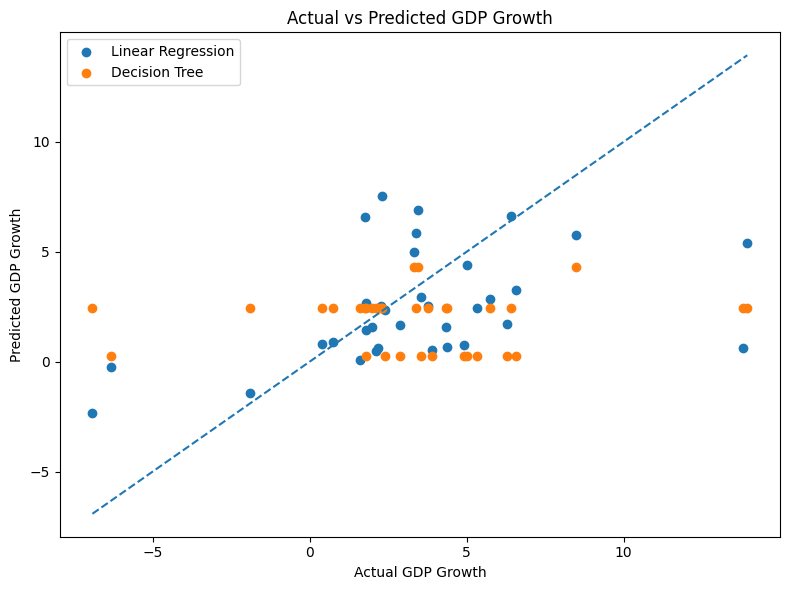

Saved figure to: ../outputs/figures/syria_ml_actual_vs_predicted_gdp_growth.png


In [16]:
# Plot actual vs predicted values

plt.figure(figsize=(8, 6))

plt.scatter(prediction_df["actual_gdp_growth"], prediction_df["linear_prediction"], label="Linear Regression")
plt.scatter(prediction_df["actual_gdp_growth"], prediction_df["tree_prediction"], label="Decision Tree")

min_value = min(
    prediction_df["actual_gdp_growth"].min(),
    prediction_df["linear_prediction"].min(),
    prediction_df["tree_prediction"].min()
)

max_value = max(
    prediction_df["actual_gdp_growth"].max(),
    prediction_df["linear_prediction"].max(),
    prediction_df["tree_prediction"].max()
)

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual GDP Growth")
plt.ylabel("Predicted GDP Growth")
plt.title("Actual vs Predicted GDP Growth")
plt.legend()
plt.tight_layout()

figure_path = FIGURE_DIR / "syria_ml_actual_vs_predicted_gdp_growth.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [17]:
# Get feature names after preprocessing

feature_names = tree_model.named_steps["preprocessor"].get_feature_names_out()

tree_importances = tree_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": tree_importances
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
3,num__inflation,0.375203
7,num__year,0.349454
15,cat__host_name_Turkey,0.183247
0,num__conflict_bd_best_syria,0.064940
1,num__refugees_per_1000,0.027157
11,cat__host_name_Jordan,0.000000
16,cat__host_group_non_neighbor_european_host,0.000000
14,cat__host_name_Sweden,0.000000
13,cat__host_name_Netherlands,0.000000
12,cat__host_name_Lebanon,0.000000


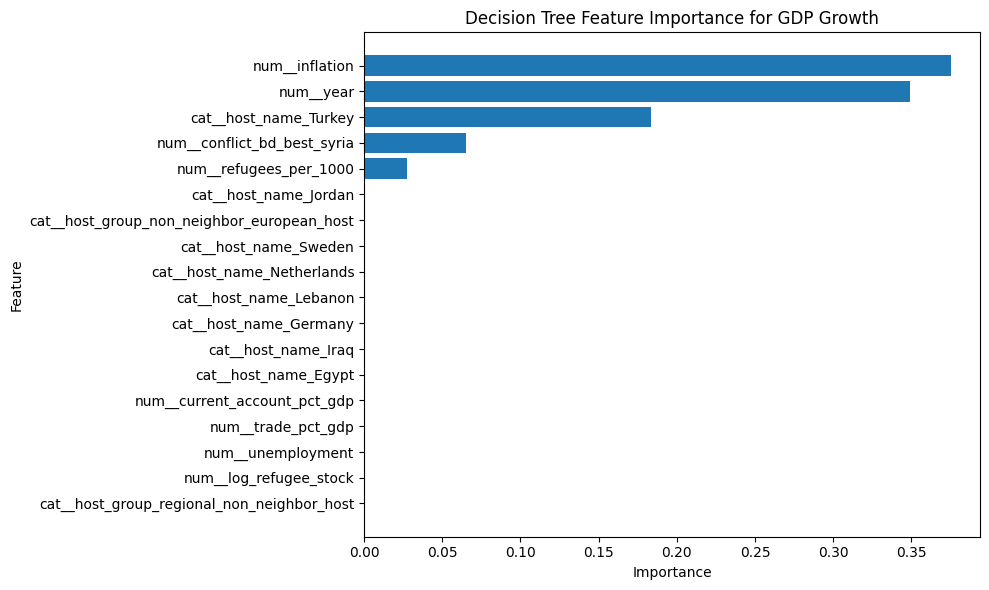

Saved figure to: ../outputs/figures/syria_ml_feature_importance_gdp_growth.png


In [18]:
# Plot feature importance

plt.figure(figsize=(10, 6))

plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance for GDP Growth")
plt.gca().invert_yaxis()
plt.tight_layout()

figure_path = FIGURE_DIR / "syria_ml_feature_importance_gdp_growth.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

## Preliminary ML Interpretation

The ML models were used to predict GDP growth using refugee exposure, conflict intensity, host-country group, and macroeconomic indicators.

The expanded dataset includes neighboring and non-neighbor Syrian refugee host countries for 2010–2024. The results are still exploratory, but the larger dataset gives a stronger basis for model comparison than the initial three-country version.

Linear Regression was used as a baseline model, while the Decision Tree Regressor was used to capture possible non-linear patterns. The models were evaluated using MAE, RMSE, and R².
